Prepared By **TAUFIQ MUSTAFIZUR RAHMAN**


---





**Task:**

 You are to write the program of a Maze Solver Agent to find a path through a maze from a
entry point to an exit point using the A* search algorithm.

Maze: For this task, the maze is of size N x M, where N is the height and M is the width of the
maze. The maze is described using 2 symbols, “0” and “#”, where “0”s denote the paths and
“#”s denote the walls. In addition, the mazes will have only one entry point and only one exit
point.

An example maze is as follows:

"###0####"

"#000000#"

"###0#00#"

"#000#00#"

"#0######"

"#000000#"

"#####0##"

Heuristic function: You need to use the Manhattan distance as the heuristic function. For two
points  (𝑥2
, 𝑦2
)
, the Manhattan distance is calculated as

|𝑥1
− 𝑥2
| + |𝑦1
− 𝑦2
|
.



Moves: The agent can move only in horizontal and vertical directions. It cannot move in
diagonal directions.


Cost: The cost of each move in the maze is 1.

Output:  
The first output will be the total path cost (number of steps required to exit the maze).  
The second output will be the sequence of actions to go from initial to goal state

 [ it will contain
a sequence of actions represented using the characters U (Up), D (Down), R (Right), and L
(Left) Print -1 if no path is found ].


In [2]:
import heapq

In [9]:
def manhattan_distance(p1,p2):
  # Calculates |x1 - x2| + |y1 - y2|
  return abs(p1[0]-p2[0]) + abs(p1[1]-p2[1])

def maze_solve(maze, start,goal):
  rows = len(maze)
  cols = len(maze[0])
  directions = [(-1,0,'U'),(1,0,'D'),(0,-1,'L'),(0,1,'R')]
  pq =[]
  # Priority queue stores tuples of: (f_score, g_score, current_node, path_string)
  heapq.heappush(pq, (manhattan_distance(start,goal),0,start,""))
  visited = set()

  while pq:
    f,g,current,path = heapq.heappop(pq)

    if current==goal:
      return g,path

    if current in visited:
      continue

    visited.add(current)

    for x,y, action in directions:
      new_x, new_y = current[0]+x, current[1]+y

      if 0<=new_x <rows and 0<=new_y<cols and maze[new_x][new_y]=='0':
        if(new_x,new_y) not in visited:
          new_g = g+1;
          new_f = new_g + manhattan_distance((new_x,new_y),goal)
          heapq.heappush(pq,(new_f,new_g,(new_x,new_y),path+action))


  return -1,""


maze = [
    "###0####",
    "#000000#",
    "###0#00#",
    "#000#00#",
    "#0######",
    "#000000#",
    "#####0##"
]

start_node  = (0,3)
goal_node = (6,5)
cost, path = maze_solve(maze, start_node, goal_node)
if cost != -1:
  print(cost)
  print(path)
else:
  print("-1")



12
DDDLLDDRRRRD


Task:

Write a program to check whether heuristic values are admissible or not.

Admissibility checker: You need to write a function that takes a graph and a set of heuristic
values as input and outputs whether the heuristic values are admissible or not.

Graph: The graph is an undirected and unweighted graph with N vertices numbered from 1
to N.

Output: Print 1 if all the heuristic values are admissible. Otherwise print 0 and mention which
nodes are not admissible.

Sample Graph:

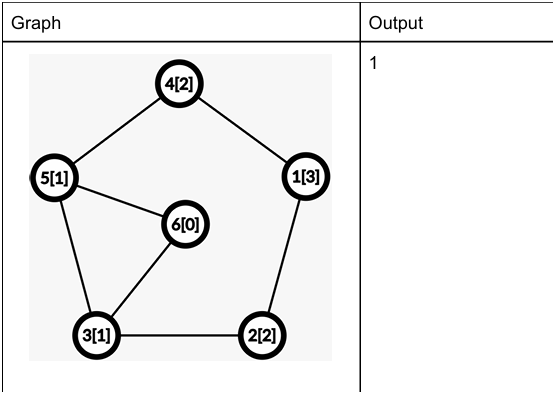

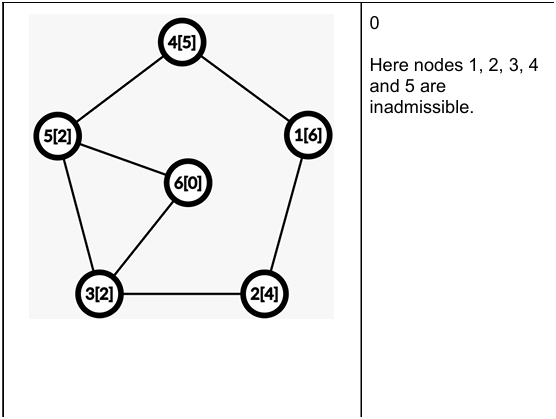

In [14]:
import heapq

def check_admissibility(graph, heuristics, goal):
    # Initialize true costs to infinity
    true_costs = {node: float('inf') for node in graph}
    true_costs[goal] = 0

    # Priority queue stores tuples of (cost, node)
    pq = [(0, goal)]

    while pq:
        # Pop the node with the lowest cost
        current_cost, current = heapq.heappop(pq)

        # If we somehow pushed a worse path to the same node earlier, skip it
        if current_cost > true_costs[current]:
            continue

        for neighbor in graph[current]:
            # In this unweighted graph, every edge has a step cost of 1
            new_cost = current_cost + 1

            # If we found a shorter path to the neighbor, update and push to queue
            if new_cost < true_costs[neighbor]:
                true_costs[neighbor] = new_cost
                heapq.heappush(pq, (new_cost, neighbor))

    inadmissible = []
    for node, h_val in heuristics.items():
        if h_val > true_costs[node]:
            inadmissible.append(node)

    if not inadmissible:
        print(1)
    else:
        print("0")
        inadmissible.sort()
        print("Inadmissible nodes are: ")
        print(inadmissible)


graph_input = {
    1: (2, 4),
    2: (1, 3),
    3: (2, 5, 6),
    4: (1, 5),
    5: (3, 4, 6),
    6: (3, 5)
}

# The node heuristic values
heuristics_input = {
    1: 3,
    2: 2,
    3: 1,
    4: 2,
    5: 1,
    6: 0
}

goal_node = 6

check_admissibility(graph_input, heuristics_input, goal_node)

1


**Task:**

You are given an undirected, weighted graph consisting of 5 nodes (A, B, C, D, E). You need to write a program that uses the $A^*$ search algorithm to find the shortest path from the starting node **A** to the goal node **E**.

**Given Data:**

 **Start Node:** A
**Goal Node:** E
 **Edge Costs $g(n)$:**

 A to B: 2

 A to C: 5

 B to C: 2

 B to D: 4

 C to E: 5

 D to E: 1


**Heuristic Values $h(n)$:** (Estimated distance to goal E)

 A: 6

 B: 4

 C: 4

 D: 1

 E: 0

**Output Requirement:**
Your program should output the total minimum cost to reach the goal and the sequence of nodes visited to achieve that path.



In [13]:
def a_star(graph, heuristics, start, goal):
    # Priority queue stores tuples: (f_score, g_score, current_node, path_taken)
    pq = []
    heapq.heappush(pq, (heuristics[start], 0, start, [start]))
    visited = set()

    while pq:
        f, g, current, path = heapq.heappop(pq)
        if current == goal:
            return g, path
        if current in visited:
            continue

        visited.add(current)

        for neighbor, move_cost in graph.get(current, ()):
            if neighbor not in visited:
                new_g = g + move_cost
                new_f = new_g + heuristics[neighbor]

                heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))

    return -1, []

graph= {
    'A': (('B', 2), ('C', 5)),
    'B': (('A', 2), ('C', 2), ('D', 4)),
    'C': (('A', 5), ('B', 2), ('E', 5)),
    'D': (('B', 4), ('E', 1)),
    'E': (('C', 5), ('D', 1))
}
heuristics = {'A': 6, 'B': 4, 'C': 4, 'D': 1, 'E': 0}

cost, optimal_path = a_star(graph, heuristics, 'A', 'E')
print(f"Total Path Cost: {cost}")
print(f"Optimal Path: {' -> '.join(optimal_path)}")

Total Path Cost: 7
Optimal Path: A -> B -> D -> E


### I. Problem Statement

**Task:**
You are given an undirected, weighted graph consisting of 5 nodes (A, B, C, D, E) and a set of heuristic values $h(n)$ representing the estimated cost to reach the goal node **E**. Your task is to determine mathematically and programmatically whether the given heuristics are:

1. **Admissible:** The heuristic never overestimates the true minimum cost to reach the goal. ($h(n) \le h^*(n)$)
2. **Consistent:** The heuristic satisfies the triangle inequality (monotone restriction) for every edge. ($h(n) \le c(n, n') + h(n')$)

**Given Data:**

* **Goal Node:** E
* **Graph Edges & Costs $c(n, n')$:**
* A-B: 2, A-C: 5, B-C: 2, B-D: 4, C-E: 5, D-E: 1


* **Heuristics $h(n)$:**
* A: 6, B: 4, C: 4, D: 1, E: 0



---

### II. Mathematical Evaluation

#### 1. Checking Admissibility

A heuristic is admissible if $h(n) \le h^*(n)$ for all nodes, where $h^*(n)$ is the true shortest path cost from node $n$ to the goal.

First, let's find the true minimum costs $h^*(n)$ to reach E:

* **E to E:** 0 $\rightarrow h^*(E) = 0$
* **D to E:** Direct edge cost is 1 $\rightarrow h^*(D) = 1$
* **C to E:** Direct edge cost is 5 $\rightarrow h^*(C) = 5$
* **B to E:** Shortest path is B $\rightarrow$ D $\rightarrow$ E (4 + 1) = 5 $\rightarrow h^*(B) = 5$
* **A to E:** Shortest path is A $\rightarrow$ B $\rightarrow$ D $\rightarrow$ E (2 + 4 + 1) = 7 $\rightarrow h^*(A) = 7$

Now, compare $h(n)$ to $h^*(n)$:

* Node A: $6 \le 7$ (Valid)
* Node B: $4 \le 5$ (Valid)
* Node C: $4 \le 5$ (Valid)
* Node D: $1 \le 1$ (Valid)
* Node E: $0 \le 0$ (Valid)

**Conclusion:** The heuristic is **Admissible**.

#### 2. Checking Consistency

A heuristic is consistent if, for every node $n$ and every connected neighbor $n'$, the estimated cost of $n$ is less than or equal to the cost of moving to $n'$ plus the estimated cost of $n'$.
Formula: $h(n) \le c(n, n') + h(n')$

Let's check all directed edges:

* **A $\leftrightarrow$ B (Cost 2):**
* A to B: $6 \le 2 + 4 \Rightarrow 6 \le 6$ (Valid)
* B to A: $4 \le 2 + 6 \Rightarrow 4 \le 8$ (Valid)


* **A $\leftrightarrow$ C (Cost 5):**
* A to C: $6 \le 5 + 4 \Rightarrow 6 \le 9$ (Valid)
* C to A: $4 \le 5 + 6 \Rightarrow 4 \le 11$ (Valid)


* **B $\leftrightarrow$ C (Cost 2):**
* B to C: $4 \le 2 + 4 \Rightarrow 4 \le 6$ (Valid)
* C to B: $4 \le 2 + 4 \Rightarrow 4 \le 6$ (Valid)


* **B $\leftrightarrow$ D (Cost 4):**
* B to D: $4 \le 4 + 1 \Rightarrow 4 \le 5$ (Valid)
* D to B: $1 \le 4 + 4 \Rightarrow 1 \le 8$ (Valid)


* **C $\leftrightarrow$ E (Cost 5):**
* C to E: $4 \le 5 + 0 \Rightarrow 4 \le 5$ (Valid)
* E to C: $0 \le 5 + 4 \Rightarrow 0 \le 9$ (Valid)


* **D $\leftrightarrow$ E (Cost 1):**
* D to E: $1 \le 1 + 0 \Rightarrow 1 \le 1$ (Valid)
* E to D: $0 \le 1 + 1 \Rightarrow 0 \le 2$ (Valid)



**Conclusion:** The heuristic is **Consistent**. (Note: Every consistent heuristic is inherently admissible, but we checked both just to be thorough).




In [16]:
import heapq

def check_admissibility(graph, heuristics, goal):
    true_costs = {node: float('inf') for node in graph}
    true_costs[goal] = 0
    pq = [(0, goal)]

    while pq:
        current_cost, current = heapq.heappop(pq)
        if current_cost > true_costs[current]:
            continue
        for neighbor, move_cost in graph[current]:
            new_cost = current_cost + move_cost
            if new_cost < true_costs[neighbor]:
                true_costs[neighbor] = new_cost
                heapq.heappush(pq, (new_cost, neighbor))

    # 2. Compare heuristic values to true costs
    inadmissible_nodes = []
    for node, h_val in heuristics.items():
        if h_val > true_costs[node]:
            inadmissible_nodes.append(node)

    if not inadmissible_nodes:
        print("Admissibility:")
    else:
        print(f"Admissibility: FALSE (Inadmissible nodes: {inadmissible_nodes})")


def check_consistency(graph, heuristics):
    inconsistent_edges = []
    for node in graph:
        for neighbor, move_cost in graph[node]:
            # If the estimated cost from the current node is greater than
            # the step cost plus the estimated cost from the neighbor
            if heuristics[node] > move_cost + heuristics[neighbor]:
                inconsistent_edges.append((node, neighbor))

    if not inconsistent_edges:
        print("Consistency: TRUE")
    else:
        print(f"Consistency: FALSE (Inconsistent edges: {inconsistent_edges})")


graph = {
    'A': (('B', 2), ('C', 5)),
    'B': (('A', 2), ('C', 2), ('D', 4)),
    'C': (('A', 5), ('B', 2), ('E', 5)),
    'D': (('B', 4), ('E', 1)),
    'E': (('C', 5), ('D', 1))
}

heuristics = {'A': 6, 'B': 4, 'C': 4, 'D': 1, 'E': 0}
goal_node = 'E'

check_admissibility(graph, heuristics, goal_node)
check_consistency(graph, heuristics)

Admissibility: TRUE (All nodes are admissible)
Consistency: TRUE


**Task:**


### Problem Statement: $A^*$ Search and Heuristic Evaluation

**Background:**
You are given an undirected, weighted graph representing a network of 5 nodes: **S, A, B, C, and G**. You are also provided with a set of heuristic values, $h(n)$, which represent the estimated cost to reach the goal node from each specific node.

**Given Data:**

* **Start Node:** S
* **Goal Node:** G
* **Edge Costs:**

  S to A: 1

  S to B: 4

  A to B: 2

  A to C: 5

  A to G: 12

  B to C: 2

  C to G: 3


* **Heuristic Values $h(n)$:**

  S: 7

  A: 6

  B: 4

  C: 2

  G: 0


**Tasks:**
Write a program that performs the following three distinct tasks:

1. **$A^*$ Search Implementation:** Utilize the $A^*$ search algorithm to find the optimal (shortest) path from the start node **S** to the goal node **G**. Output the total path cost and the sequence of nodes visited.
2. **Admissibility Check:** Determine if the given heuristic is admissible. A heuristic is admissible if $h(n) \le h^*(n)$ for all nodes, where $h^*(n)$ is the true minimum cost from node $n$ to the goal. Output whether it is admissible, and if not, list the nodes that fail the condition.
3. **Consistency Check:** Determine if the given heuristic is consistent. A heuristic is consistent if it satisfies the triangle inequality $h(n) \le c(n, n') + h(n')$ for every edge connecting node $n$ to node $n'$. Output whether it is consistent, and if not, list the edges that fail the condition.

In [18]:
import heapq

def run_astar(graph, heuristics, start, goal):
    pq = []
    heapq.heappush(pq, (heuristics[start], 0, start, [start]))
    visited = set()

    while pq:
        f, g, current, path = heapq.heappop(pq)

        if current == goal:
            return g, path

        if current in visited:
            continue
        visited.add(current)

        for neighbor, move_cost in graph.get(current, ()):
            if neighbor not in visited:
                new_g = g + move_cost
                new_f = new_g + heuristics[neighbor]
                heapq.heappush(pq, (new_f, new_g, neighbor, path + [neighbor]))

    return -1, []

def check_admissibility(graph, heuristics, goal):
    true_costs = {node: float('inf') for node in graph}
    true_costs[goal] = 0
    pq = [(0, goal)]

    while pq:
        current_cost, current = heapq.heappop(pq)

        if current_cost > true_costs[current]:
            continue

        for neighbor, move_cost in graph.get(current, ()):
            new_cost = current_cost + move_cost
            if new_cost < true_costs[neighbor]:
                true_costs[neighbor] = new_cost
                heapq.heappush(pq, (new_cost, neighbor))

    inadmissible = [node for node, h_val in heuristics.items() if h_val > true_costs[node]]

    if not inadmissible:
        print("Admissibility: TRUE ")
    else:
        print(f"Admissibility: FALSE (Failing nodes: {inadmissible})")

def check_consistency(graph, heuristics):
    # Compare h(n) <= c(n, n') + h(n') for all edges
    inconsistent_edges = []

    for node in graph:
        for neighbor, move_cost in graph[node]:
            if heuristics[node] > move_cost + heuristics[neighbor]:
                inconsistent_edges.append((node, neighbor))

    if not inconsistent_edges:
        print("Consistency: TRUE")
    else:
        print(f"Consistency: FALSE (Failing edges: {inconsistent_edges})")

graph_input = {
    'S': (('A', 1), ('B', 4)),
    'A': (('S', 1), ('B', 2), ('C', 5), ('G', 12)),
    'B': (('S', 4), ('A', 2), ('C', 2)),
    'C': (('A', 5), ('B', 2), ('G', 3)),
    'G': (('A', 12), ('C', 3))
}

heuristics_input = {
    'S': 7,
    'A': 6,
    'B': 4,
    'C': 2,
    'G': 0
}

start_node = 'S'
goal_node = 'G'

print("--- Running A* Search ---")
cost, path = run_astar(graph_input, heuristics_input, start_node, goal_node)
if cost != -1:
    print(f"Total Path Cost: {cost}")
    print(f"Optimal Path: {' -> '.join(path)}")
else:
    print("No path found.")

print("\n--- Running Heuristic Checks ---")
check_admissibility(graph_input, heuristics_input, goal_node)
check_consistency(graph_input, heuristics_input)

--- Running A* Search ---
Total Path Cost: 8
Optimal Path: S -> A -> B -> C -> G

--- Running Heuristic Checks ---
Admissibility: TRUE 
Consistency: TRUE
